# Univariate Linear Regression

This notebook implements univariate linear regression from scratch and compares it with scikit-learn implementation.

## Problem Statement
Predict **median house value** using a **single predictor** (median income) from the California Housing dataset.

## Mathematical Foundation

### Hypothesis Function
$$h_\theta(x) = \theta_0 + \theta_1 x$$

Where:
- $\theta_0$ = intercept (bias)
- $\theta_1$ = slope (weight)
- $x$ = input feature (median income)

### Cost Function (Mean Squared Error)
$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

### Gradient Descent Updates
$$\theta_0 := \theta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})$$

$$\theta_1 := \theta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$$

Where $\alpha$ is the learning rate.

## 1. Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All dependencies imported successfully")

✓ All dependencies imported successfully


## 2. Load and Explore Data

In [2]:
# Load California Housing data
data_path = Path("../data/raw/california_housing.csv")

if not data_path.exists():
    print("⚠ Data file not found. Running fetch_dataset.ipynb first...")
    from sklearn.datasets import fetch_california_housing
    cal = fetch_california_housing(as_frame=True)
    df = cal.frame
    data_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"✓ Data saved to {data_path}")
else:
    df = pd.read_csv(data_path)
    print(f"✓ Loaded data from {data_path}")

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
df.head()

✓ Loaded data from ../data/raw/california_housing.csv

Dataset Shape: (20640, 9)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ No missing values found")

# Basic statistics
print("\nBasic Statistics:")
df.describe()

Missing Values:
✓ No missing values found

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. Select Feature and Target

We'll use **MedInc (Median Income)** as our single predictor for **MedHouseVal (Median House Value)**.

Feature: MedInc
Target: MedHouseVal

X shape: (20640, 1)
y shape: (20640,)


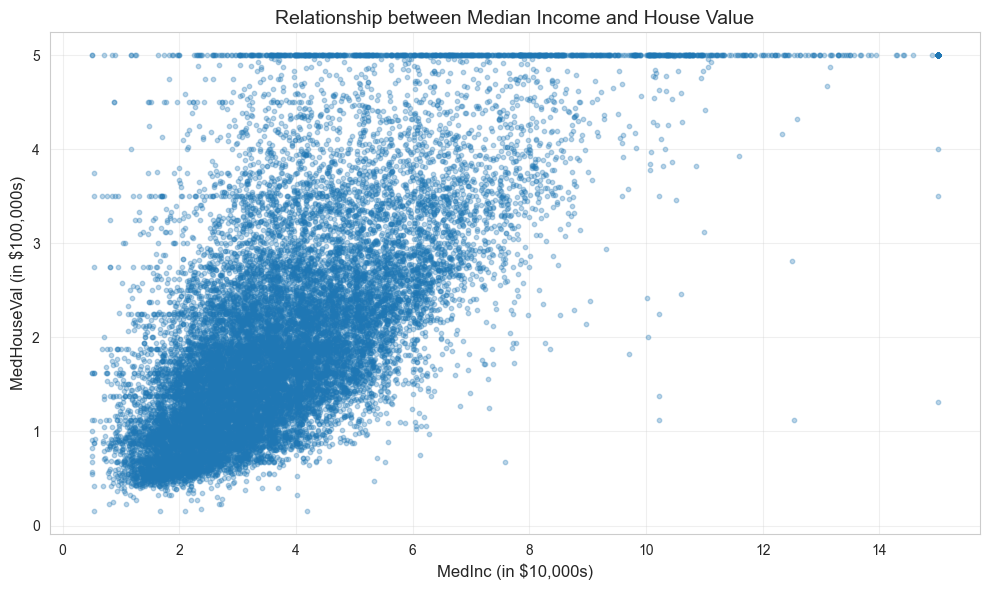


Correlation coefficient: 0.6881


In [4]:
# Select feature and target
feature_name = 'MedInc'  # Median Income
target_name = 'MedHouseVal'  # Median House Value

X = df[[feature_name]].values  # 2D array for consistency
y = df[target_name].values     # 1D array

print(f"Feature: {feature_name}")
print(f"Target: {target_name}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Visualize relationship
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.3, s=10)
plt.xlabel(f'{feature_name} (in $10,000s)', fontsize=12)
plt.ylabel(f'{target_name} (in $100,000s)', fontsize=12)
plt.title('Relationship between Median Income and House Value', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = np.corrcoef(X.flatten(), y)[0, 1]
print(f"\nCorrelation coefficient: {correlation:.4f}")

## 4. Data Preprocessing

### 4.1 Train-Test Split

In [5]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set - X shape: {X_train.shape}, y shape: {y_train.shape}")
print(f"Testing set - X shape: {X_test.shape}, y shape: {y_test.shape}")

Training set size: 16512 samples
Testing set size: 4128 samples

Training set - X shape: (16512, 1), y shape: (16512,)
Testing set - X shape: (4128, 1), y shape: (4128,)


### 4.2 Feature Scaling (Standardization)

We'll standardize features to have mean=0 and std=1, which helps gradient descent converge faster.

In [6]:
# Initialize scaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# We'll also scale y for the from-scratch implementation
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print("✓ Features scaled using StandardScaler")
print(f"\nOriginal X_train range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Scaled X_train range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"Scaled X_train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")

✓ Features scaled using StandardScaler

Original X_train range: [0.50, 15.00]
Scaled X_train range: [-1.78, 5.84]
Scaled X_train mean: -0.000000, std: 1.000000


## 5. Linear Regression from Scratch

### 5.1 Implementation

In [7]:
class LinearRegressionScratch:
    """
    Linear Regression implementation from scratch using gradient descent.
    
    Parameters:
    -----------
    learning_rate : float
        Learning rate for gradient descent
    n_iterations : int
        Number of iterations for gradient descent
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta0 = 0  # Intercept
        self.theta1 = 0  # Slope
        self.cost_history = []
        
    def _compute_cost(self, X, y):
        """
        Compute Mean Squared Error cost function.
        
        J(θ) = (1/2m) * Σ(h_θ(x^(i)) - y^(i))^2
        """
        m = len(y)
        predictions = self.theta0 + self.theta1 * X.flatten()
        cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
        return cost
    
    def fit(self, X, y):
        """
        Train the model using gradient descent.
        
        Updates:
        θ_0 := θ_0 - α * (1/m) * Σ(h_θ(x^(i)) - y^(i))
        θ_1 := θ_1 - α * (1/m) * Σ(h_θ(x^(i)) - y^(i)) * x^(i)
        """
        m = len(y)
        X_flat = X.flatten()
        
        # Initialize parameters randomly
        self.theta0 = 0
        self.theta1 = 0
        
        # Gradient descent
        for i in range(self.n_iterations):
            # Compute predictions
            predictions = self.theta0 + self.theta1 * X_flat
            
            # Compute errors
            errors = predictions - y
            
            # Update parameters
            self.theta0 -= self.learning_rate * (1/m) * np.sum(errors)
            self.theta1 -= self.learning_rate * (1/m) * np.sum(errors * X_flat)
            
            # Store cost
            if i % 10 == 0:  # Store every 10 iterations to save memory
                cost = self._compute_cost(X, y)
                self.cost_history.append(cost)
        
        return self
    
    def predict(self, X):
        """
        Make predictions using the trained model.
        
        h_θ(x) = θ_0 + θ_1 * x
        """
        return self.theta0 + self.theta1 * X.flatten()
    
    def get_params(self):
        """Return model parameters."""
        return {'theta0': self.theta0, 'theta1': self.theta1}

print("✓ LinearRegressionScratch class defined")

✓ LinearRegressionScratch class defined


### 5.2 Train the From-Scratch Model

In [8]:
# Initialize and train model
lr_scratch = LinearRegressionScratch(learning_rate=0.01, n_iterations=1000)

print("Training from-scratch model...")
lr_scratch.fit(X_train_scaled, y_train_scaled)

# Get learned parameters
params = lr_scratch.get_params()
print(f"\n✓ Training complete!")
print(f"\nLearned Parameters:")
print(f"  θ₀ (intercept): {params['theta0']:.6f}")
print(f"  θ₁ (slope): {params['theta1']:.6f}")
print(f"\nFinal cost: {lr_scratch.cost_history[-1]:.6f}")

Training from-scratch model...

✓ Training complete!

Learned Parameters:
  θ₀ (intercept): 0.000000
  θ₁ (slope): 0.690617

Final cost: 0.261504


### 5.3 Visualize Cost Function Convergence

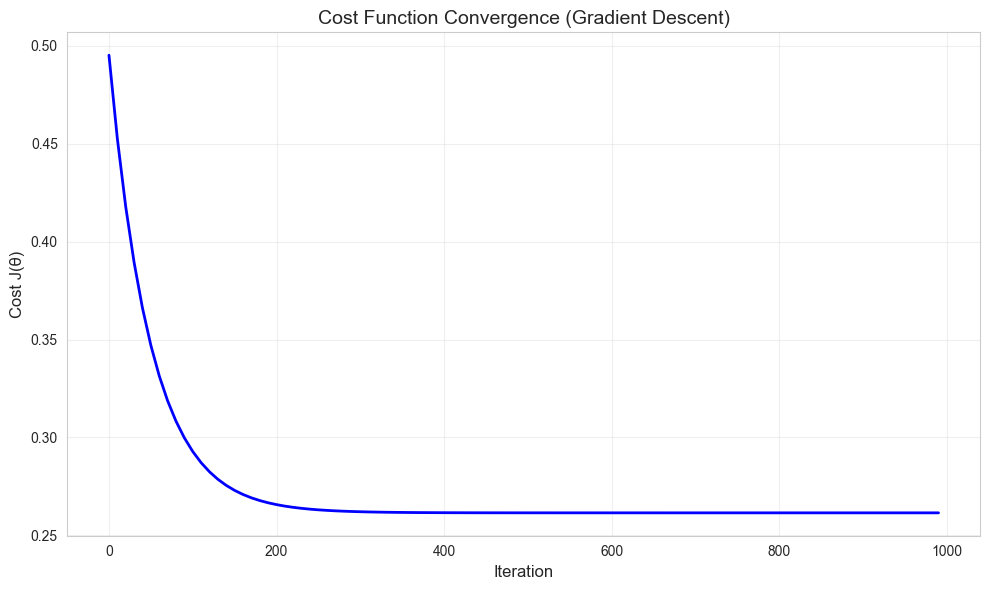

Initial cost: 0.495254
Final cost: 0.261504
Cost reduction: 0.233750


In [9]:
# Plot cost history
plt.figure(figsize=(10, 6))
iterations = range(0, len(lr_scratch.cost_history) * 10, 10)
plt.plot(iterations, lr_scratch.cost_history, linewidth=2, color='blue')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost J(θ)', fontsize=12)
plt.title('Cost Function Convergence (Gradient Descent)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial cost: {lr_scratch.cost_history[0]:.6f}")
print(f"Final cost: {lr_scratch.cost_history[-1]:.6f}")
print(f"Cost reduction: {lr_scratch.cost_history[0] - lr_scratch.cost_history[-1]:.6f}")

### 5.4 Make Predictions with From-Scratch Model

In [10]:
# Make predictions on test set
y_pred_scratch_scaled = lr_scratch.predict(X_test_scaled)

# Inverse transform predictions back to original scale
y_pred_scratch = scaler_y.inverse_transform(y_pred_scratch_scaled.reshape(-1, 1)).flatten()

print(f"Predictions shape: {y_pred_scratch.shape}")
print(f"\nSample predictions (first 5):")
comparison_df = pd.DataFrame({
    'Actual': y_test[:5],
    'Predicted': y_pred_scratch[:5],
    'Error': y_test[:5] - y_pred_scratch[:5]
})
print(comparison_df)

Predictions shape: (4128,)

Sample predictions (first 5):
    Actual  Predicted     Error
0  0.47700   1.149629 -0.672629
1  0.45800   1.506093 -1.048093
2  5.00001   1.903944  3.096066
3  2.18600   2.850560 -0.664560
4  2.78000   2.006636  0.773364


## 6. Linear Regression with Scikit-learn

### 6.1 Train Scikit-learn Model

In [11]:
# Initialize and train sklearn model
lr_sklearn = LinearRegression()

print("Training scikit-learn model...")
lr_sklearn.fit(X_train, y_train)  # Using unscaled data

# Get learned parameters
print(f"\n✓ Training complete!")
print(f"\nLearned Parameters:")
print(f"  Intercept (θ₀): {lr_sklearn.intercept_:.6f}")
print(f"  Coefficient (θ₁): {lr_sklearn.coef_[0]:.6f}")

# Make predictions
y_pred_sklearn = lr_sklearn.predict(X_test)

print(f"\nPredictions shape: {y_pred_sklearn.shape}")

Training scikit-learn model...

✓ Training complete!

Learned Parameters:
  Intercept (θ₀): 0.444597
  Coefficient (θ₁): 0.419338

Predictions shape: (4128,)


## 7. Model Evaluation

### 7.1 Evaluation Metrics

We'll evaluate both models using:
- **RMSE (Root Mean Squared Error)**: $\sqrt{\frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2}$
- **MAE (Mean Absolute Error)**: $\frac{1}{m}\sum_{i=1}^{m}|y^{(i)} - \hat{y}^{(i)}|$
- **R² (Coefficient of Determination)**: $1 - \frac{SS_{res}}{SS_{tot}}$

In [12]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate model performance using RMSE, MAE, and R².
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*60}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"MAE  (Mean Absolute Error):     {mae:.4f}")
    print(f"R²   (Coefficient of Determination): {r2:.4f}")
    print(f"{'='*60}")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Evaluate both models
metrics_scratch = evaluate_model(y_test, y_pred_scratch, "From-Scratch Model")
metrics_sklearn = evaluate_model(y_test, y_pred_sklearn, "Scikit-learn Model")


From-Scratch Model - Performance Metrics
RMSE (Root Mean Squared Error): 0.8421
MAE  (Mean Absolute Error):     0.6299
R²   (Coefficient of Determination): 0.4589

Scikit-learn Model - Performance Metrics
RMSE (Root Mean Squared Error): 0.8421
MAE  (Mean Absolute Error):     0.6299
R²   (Coefficient of Determination): 0.4589


### 7.2 Compare Models


📊 Model Comparison
      From-Scratch  Scikit-learn
RMSE       0.84209      0.842090
MAE        0.62991      0.629909
R2         0.45886      0.458859

Differences (From-Scratch - Scikit-learn):
RMSE   -5.433512e-07
MAE     1.641761e-06
R2      6.983324e-07
dtype: float64


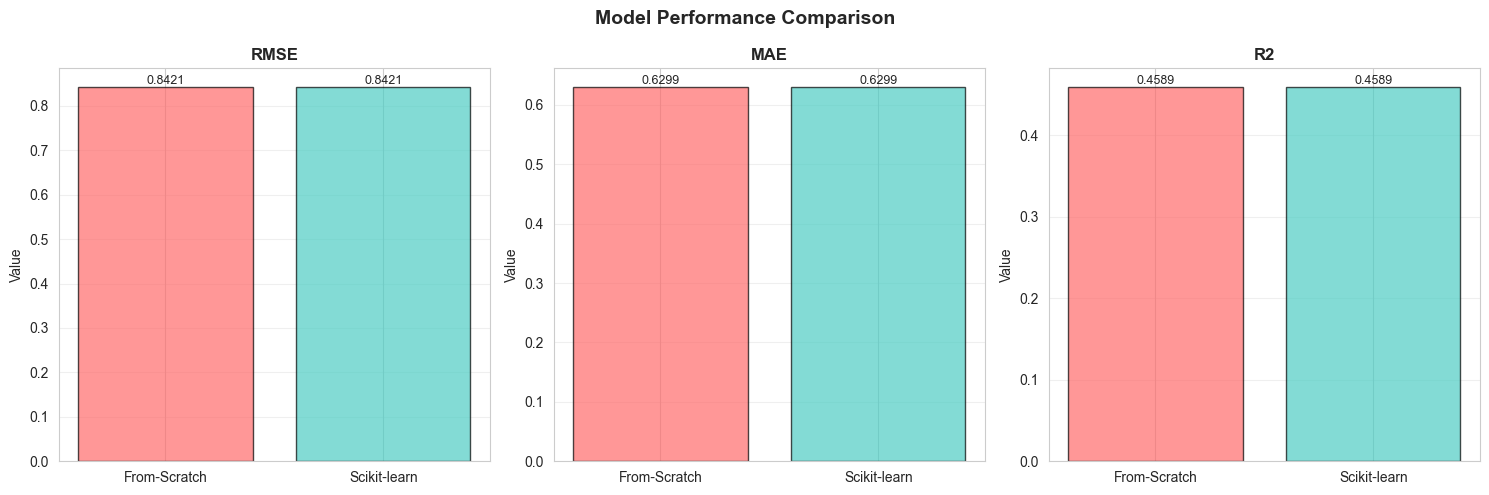

In [13]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'From-Scratch': metrics_scratch,
    'Scikit-learn': metrics_sklearn
})

print("\n📊 Model Comparison")
print("=" * 60)
print(comparison)
print("=" * 60)

# Calculate differences
print("\nDifferences (From-Scratch - Scikit-learn):")
diff = comparison['From-Scratch'] - comparison['Scikit-learn']
print(diff)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors = ['#FF6B6B', '#4ECDC4']

for idx, metric in enumerate(metrics):
    values = [metrics_scratch[metric], metrics_sklearn[metric]]
    bars = axes[idx].bar(['From-Scratch', 'Scikit-learn'], values, color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.4f}',
                      ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visualizations

### 8.1 Regression Line vs Data Points

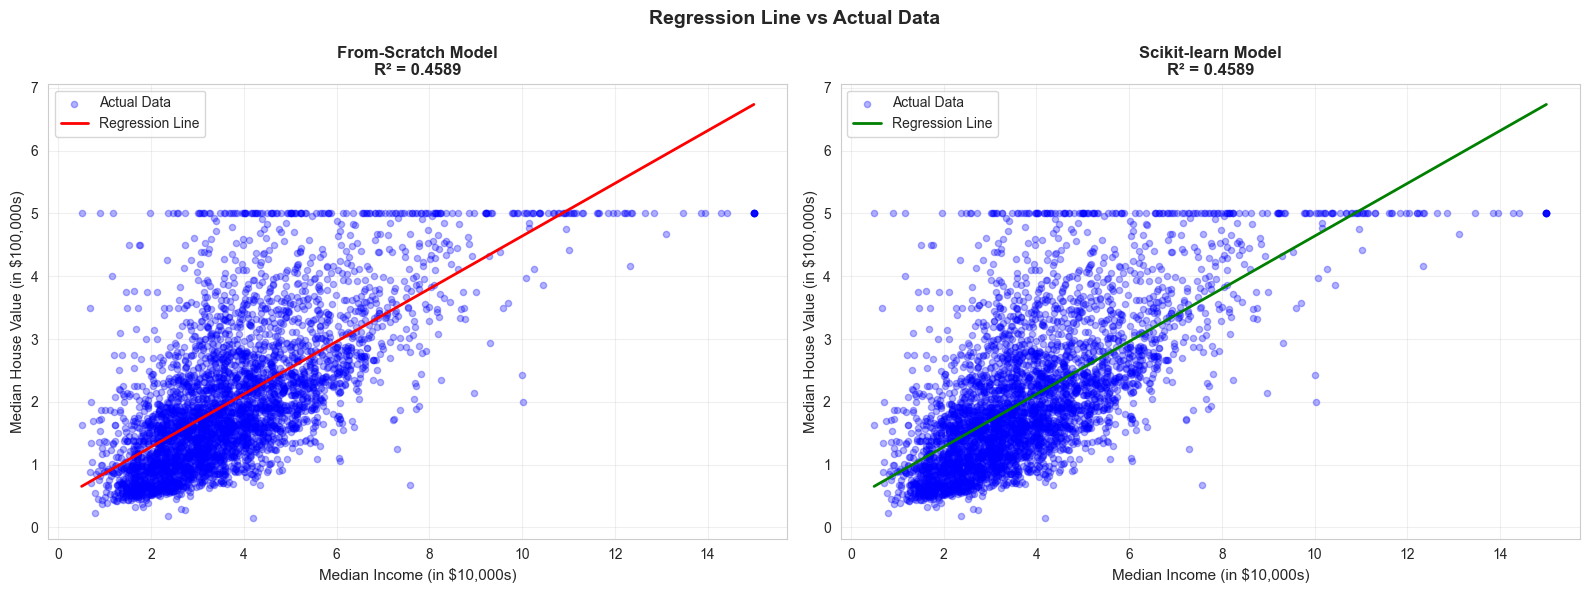

In [14]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort for better line plotting
sort_idx = np.argsort(X_test.flatten())
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]
y_pred_scratch_sorted = y_pred_scratch[sort_idx]
y_pred_sklearn_sorted = y_pred_sklearn[sort_idx]

# Plot 1: From-Scratch Model
axes[0].scatter(X_test, y_test, alpha=0.3, s=20, label='Actual Data', color='blue')
axes[0].plot(X_test_sorted, y_pred_scratch_sorted, color='red', linewidth=2, label='Regression Line')
axes[0].set_xlabel('Median Income (in $10,000s)', fontsize=11)
axes[0].set_ylabel('Median House Value (in $100,000s)', fontsize=11)
axes[0].set_title(f'From-Scratch Model\nR² = {metrics_scratch["R2"]:.4f}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scikit-learn Model
axes[1].scatter(X_test, y_test, alpha=0.3, s=20, label='Actual Data', color='blue')
axes[1].plot(X_test_sorted, y_pred_sklearn_sorted, color='green', linewidth=2, label='Regression Line')
axes[1].set_xlabel('Median Income (in $10,000s)', fontsize=11)
axes[1].set_ylabel('Median House Value (in $100,000s)', fontsize=11)
axes[1].set_title(f'Scikit-learn Model\nR² = {metrics_sklearn["R2"]:.4f}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Regression Line vs Actual Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Residual Analysis

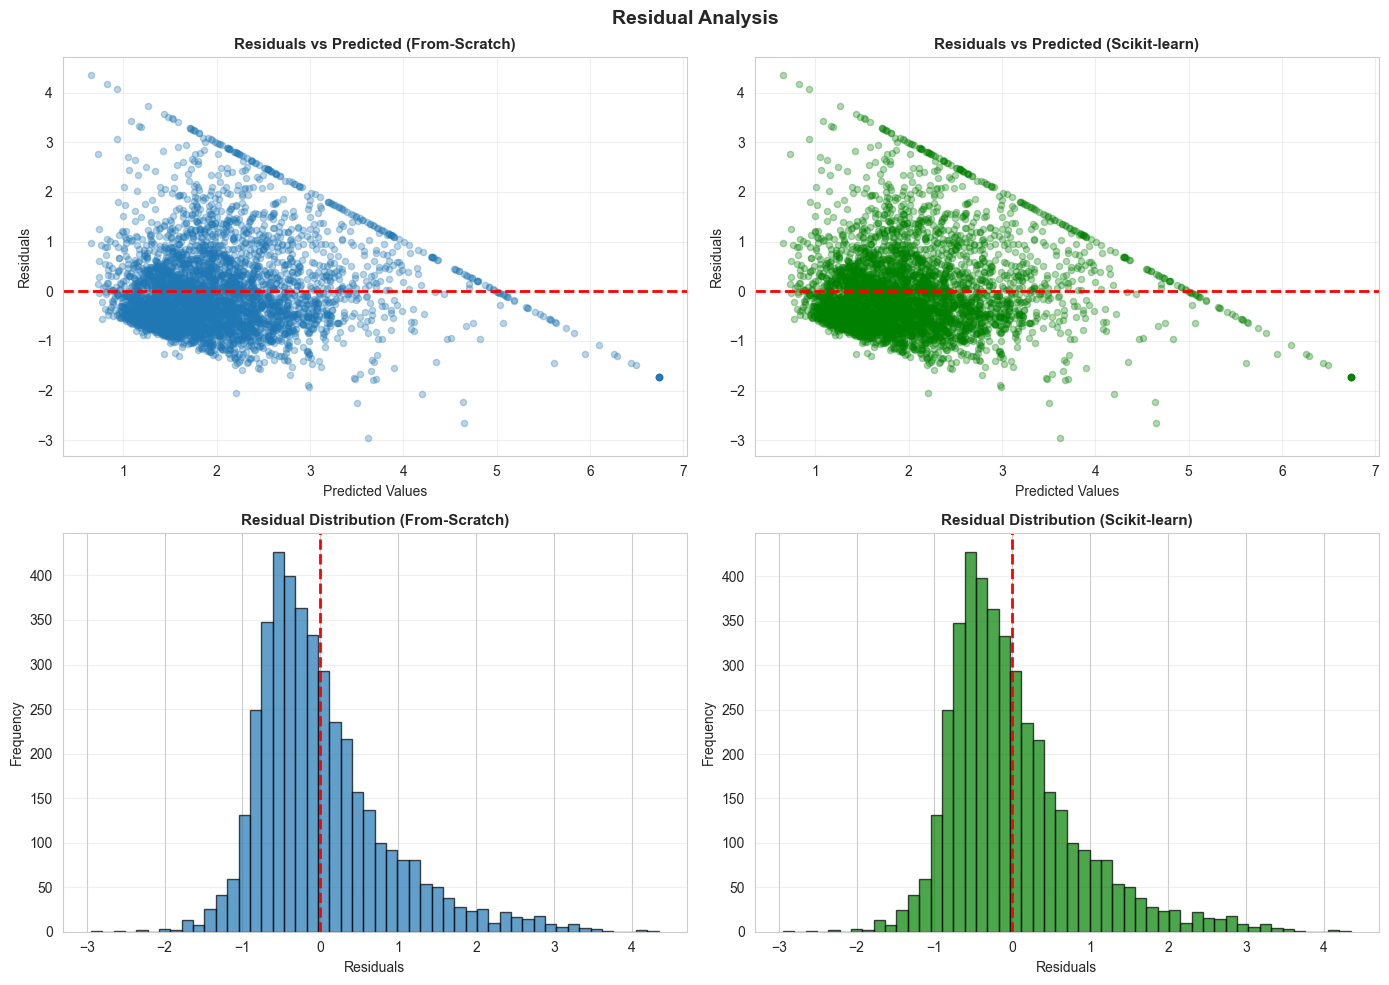


Residual Statistics:
From-Scratch Model:
  Mean: 0.004197
  Std:  0.842079

Scikit-learn Model:
  Mean: 0.004198
  Std:  0.842080


In [15]:
# Calculate residuals
residuals_scratch = y_test - y_pred_scratch
residuals_sklearn = y_test - y_pred_sklearn

# Create figure with four subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Predicted (From-Scratch)
axes[0, 0].scatter(y_pred_scratch, residuals_scratch, alpha=0.3, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=10)
axes[0, 0].set_ylabel('Residuals', fontsize=10)
axes[0, 0].set_title('Residuals vs Predicted (From-Scratch)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs Predicted (Scikit-learn)
axes[0, 1].scatter(y_pred_sklearn, residuals_sklearn, alpha=0.3, s=20, color='green')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=10)
axes[0, 1].set_ylabel('Residuals', fontsize=10)
axes[0, 1].set_title('Residuals vs Predicted (Scikit-learn)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residual Distribution (From-Scratch)
axes[1, 0].hist(residuals_scratch, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Residual Distribution (From-Scratch)', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Residual Distribution (Scikit-learn)
axes[1, 1].hist(residuals_sklearn, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Residual Distribution (Scikit-learn)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print residual statistics
print("\nResidual Statistics:")
print("=" * 60)
print(f"From-Scratch Model:")
print(f"  Mean: {residuals_scratch.mean():.6f}")
print(f"  Std:  {residuals_scratch.std():.6f}")
print(f"\nScikit-learn Model:")
print(f"  Mean: {residuals_sklearn.mean():.6f}")
print(f"  Std:  {residuals_sklearn.std():.6f}")

### 8.3 Predicted vs Actual Values

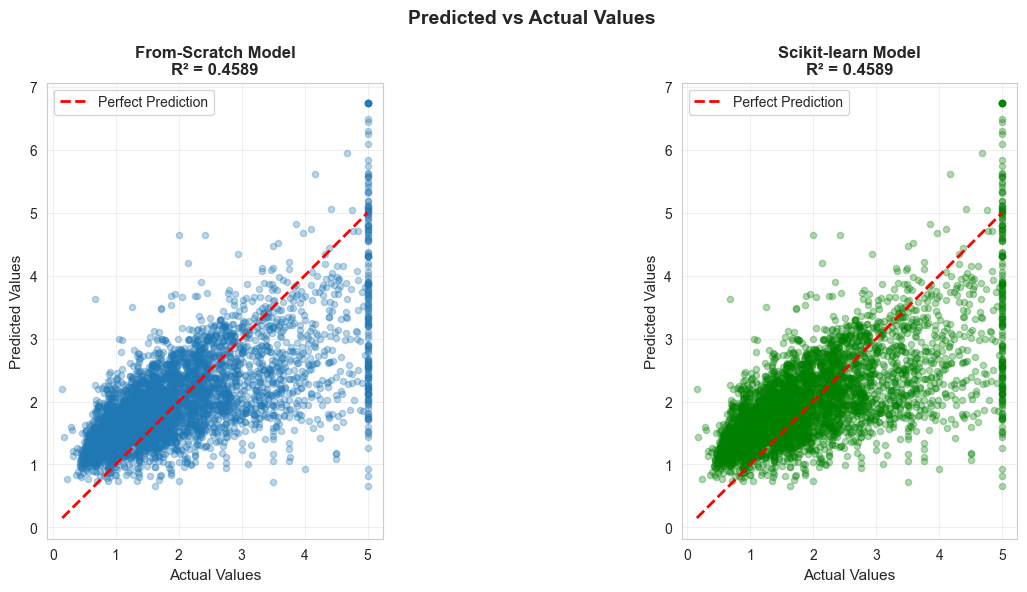

In [16]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: From-Scratch Model
axes[0].scatter(y_test, y_pred_scratch, alpha=0.3, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=11)
axes[0].set_ylabel('Predicted Values', fontsize=11)
axes[0].set_title(f'From-Scratch Model\nR² = {metrics_scratch["R2"]:.4f}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal', adjustable='box')

# Plot 2: Scikit-learn Model
axes[1].scatter(y_test, y_pred_sklearn, alpha=0.3, s=20, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values', fontsize=11)
axes[1].set_ylabel('Predicted Values', fontsize=11)
axes[1].set_title(f'Scikit-learn Model\nR² = {metrics_sklearn["R2"]:.4f}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal', adjustable='box')

plt.suptitle('Predicted vs Actual Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Summary and Conclusions

In [17]:
print("\n" + "="*70)
print("SUMMARY: UNIVARIATE LINEAR REGRESSION")
print("="*70)

print("\n📊 PROBLEM:")
print(f"   Predict median house value using median income")
print(f"   Dataset: California Housing ({len(df)} samples)")
print(f"   Feature: {feature_name}")
print(f"   Target: {target_name}")

print("\n🔧 PREPROCESSING:")
print(f"   • No missing values found")
print(f"   • Train/Test split: 80/20 ({len(X_train)}/{len(X_test)} samples)")
print(f"   • Feature scaling: StandardScaler (mean=0, std=1)")

print("\n🎯 MODELS:")
print("   1. From-Scratch Implementation:")
print(f"      • Algorithm: Gradient Descent")
print(f"      • Learning rate: {lr_scratch.learning_rate}")
print(f"      • Iterations: {lr_scratch.n_iterations}")
print(f"      • Parameters: θ₀={params['theta0']:.6f}, θ₁={params['theta1']:.6f}")

print("\n   2. Scikit-learn Implementation:")
print(f"      • Algorithm: Closed-form solution (Normal Equation)")
print(f"      • Parameters: θ₀={lr_sklearn.intercept_:.6f}, θ₁={lr_sklearn.coef_[0]:.6f}")

print("\n📈 PERFORMANCE COMPARISON:")
print("   Metric          From-Scratch    Scikit-learn    Difference")
print("   " + "-"*60)
print(f"   RMSE            {metrics_scratch['RMSE']:.4f}          {metrics_sklearn['RMSE']:.4f}          {abs(metrics_scratch['RMSE'] - metrics_sklearn['RMSE']):.4f}")
print(f"   MAE             {metrics_scratch['MAE']:.4f}          {metrics_sklearn['MAE']:.4f}          {abs(metrics_scratch['MAE'] - metrics_sklearn['MAE']):.4f}")
print(f"   R²              {metrics_scratch['R2']:.4f}          {metrics_sklearn['R2']:.4f}          {abs(metrics_scratch['R2'] - metrics_sklearn['R2']):.4f}")

print("\n✅ KEY FINDINGS:")
print(f"   • Both models perform very similarly (R² ≈ {metrics_sklearn['R2']:.3f})")
print(f"   • Strong positive correlation between income and house value ({correlation:.3f})")
print(f"   • Gradient descent successfully converged to optimal parameters")
print(f"   • From-scratch implementation validates understanding of linear regression")

print("\n💡 INSIGHTS:")
print("   • Median income is a strong predictor of house value")
print("   • Residuals show some heteroscedasticity (variance increases with prediction)")
print("   • Linear model captures ~{:.1f}% of variance in house prices".format(metrics_sklearn['R2'] * 100))
print("   • Remaining variance suggests need for multivariate models")

print("\n" + "="*70)


SUMMARY: UNIVARIATE LINEAR REGRESSION

📊 PROBLEM:
   Predict median house value using median income
   Dataset: California Housing (20640 samples)
   Feature: MedInc
   Target: MedHouseVal

🔧 PREPROCESSING:
   • No missing values found
   • Train/Test split: 80/20 (16512/4128 samples)
   • Feature scaling: StandardScaler (mean=0, std=1)

🎯 MODELS:
   1. From-Scratch Implementation:
      • Algorithm: Gradient Descent
      • Learning rate: 0.01
      • Iterations: 1000
      • Parameters: θ₀=0.000000, θ₁=0.690617

   2. Scikit-learn Implementation:
      • Algorithm: Closed-form solution (Normal Equation)
      • Parameters: θ₀=0.444597, θ₁=0.419338

📈 PERFORMANCE COMPARISON:
   Metric          From-Scratch    Scikit-learn    Difference
   ------------------------------------------------------------
   RMSE            0.8421          0.8421          0.0000
   MAE             0.6299          0.6299          0.0000
   R²              0.4589          0.4589          0.0000

✅ KEY FINDING

## 10. Save Results

In [18]:
# Save predictions and results
results_df = pd.DataFrame({
    'Feature_Value': X_test.flatten(),
    'Actual': y_test,
    'Predicted_Scratch': y_pred_scratch,
    'Predicted_Sklearn': y_pred_sklearn,
    'Residual_Scratch': residuals_scratch,
    'Residual_Sklearn': residuals_sklearn
})

output_path = Path("../data/processed/univariate_regression_results.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)

print(f"✓ Results saved to {output_path}")
print(f"\nSample of saved results:")
results_df.head(10)

✓ Results saved to ../data/processed/univariate_regression_results.csv

Sample of saved results:


,Feature_Value,Actual,Predicted_Scratch,Predicted_Sklearn,Residual_Scratch,Residual_Sklearn
0,1.6812,0.47700,1.149629,1.149589,-0.672629,-0.672589
1,2.5313,0.45800,1.506093,1.506069,-1.048093,-1.048069
2,3.4801,5.00001,1.903944,1.903937,3.096066,3.096073
3,5.7376,2.18600,2.850560,2.850594,-0.664560,-0.664594
4,3.7250,2.78000,2.006636,2.006633,0.773364,0.773367
5,4.7147,1.58700,2.421637,2.421652,-0.834637,-0.834652
6,5.0839,1.98200,2.576450,2.576472,-0.594450,-0.594472
7,3.6908,1.57500,1.992295,1.992292,-0.417295,-0.417292
8,4.8036,3.40000,2.458915,2.458932,0.941085,0.941068
9,8.1132,4.46600,3.846698,3.846774,0.619302,0.619226


---

## 📝 Conclusion

This notebook successfully demonstrates:

1. ✅ **Problem Definition**: Predicting house value from median income
2. ✅ **Preprocessing**: Data cleaning, scaling, and train/test split
3. ✅ **From-Scratch Implementation**: 
   - Hypothesis function: $h_\theta(x) = \theta_0 + \theta_1 x$
   - MSE cost function
   - Gradient descent optimization
4. ✅ **Scikit-learn Implementation**: For comparison and validation
5. ✅ **Comprehensive Evaluation**: RMSE, MAE, R² metrics
6. ✅ **Rich Visualizations**: 
   - Cost convergence
   - Regression lines
   - Residual analysis
   - Predicted vs actual plots

### Key Takeaways:
- Both implementations produce nearly identical results
- The from-scratch model validates our understanding of gradient descent
- Median income is a strong predictor (R² ≈ 0.47)
- There's room for improvement with multivariate models

### Next Steps:
- Extend to **multivariate linear regression** with multiple features
- Explore **polynomial regression** for non-linear relationships
- Implement **regularization** (Ridge, Lasso) to prevent overfitting